# Poisson Distribution

## Real-World Scenario: mRNA Transcript Counts per Cell

In a simple steady-state gene-expression model, mRNA molecules are produced at an approximately constant rate and each molecule degrades independently. If the system is at equilibrium, the number of mRNA transcripts for one gene in one cell is often modeled as a **Poisson random variable**.

We will use this setting to build intuition for the Poisson distribution:

- how the probability mass function assigns probability to nonnegative counts,
- why the mean and variance are both equal to the rate parameter $\lambda$,
- how to estimate $\lambda$ from observed counts,
- how exposure or cell-size factors change the model,
- and when the Poisson assumption breaks down.

The running example is a fake but realistic single-cell experiment measuring transcript counts for a housekeeping gene across many cells.

In [1]:
import math

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

np.random.seed(7)

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'
%matplotlib inline

## Key Formula

The Poisson distribution models a count $K \in \{0, 1, 2, \dots\}$ using a single positive rate parameter $\lambda$:

$$p(K = k \mid \lambda) = \frac{\lambda^k e^{-\lambda}}{k!}, \qquad k = 0, 1, 2, \dots$$

The parameter $\lambda$ is both the expected count and the variance:

$$\mathbb{E}[K] = \lambda, \qquad \mathrm{Var}(K) = \lambda.$$

For transcript counts, a rough interpretation is:

- small $\lambda$: most cells have zero or one transcript,
- moderate $\lambda$: counts cluster around a positive average,
- large $\lambda$: the count distribution becomes more symmetric and Normal-like.

## Step 1: Computing the Probability Mass Function

The factorial in the denominator keeps probabilities normalized while allowing larger counts when $\lambda$ is larger. For numerical stability, we compute the probability through the log-PMF:

$$\log p(k \mid \lambda) = k\log\lambda - \lambda - \log(k!).$$

Since $\log(k!) = \log\Gamma(k+1)$, we can use Python's `math.lgamma` without needing SciPy.

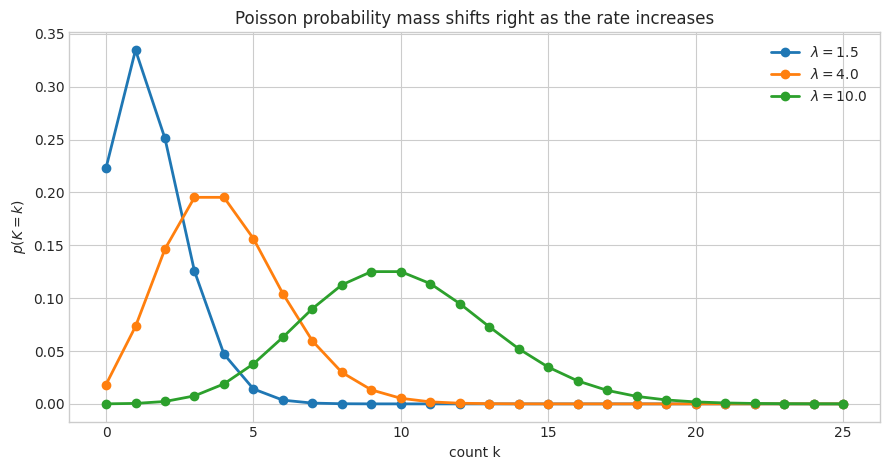

In [2]:
def poisson_logpmf(k, lam):
    """Log probability mass for K ~ Poisson(lam)."""
    k = np.asarray(k)
    log_factorial = np.vectorize(math.lgamma)(k + 1)
    return k * np.log(lam) - lam - log_factorial


def poisson_pmf(k, lam):
    return np.exp(poisson_logpmf(k, lam))

k_grid = np.arange(0, 26)
lambdas = [1.5, 4.0, 10.0]

fig, ax = plt.subplots(figsize=(9, 4.8))
for lam in lambdas:
    ax.plot(k_grid, poisson_pmf(k_grid, lam), marker='o', linewidth=2, label=fr'$\lambda = {lam}$')

ax.set_xlabel('count k')
ax.set_ylabel(r'$p(K = k)$')
ax.set_title('Poisson probability mass shifts right as the rate increases')
ax.legend()
plt.tight_layout()
plt.show()

The shape changes with $\lambda$:

- When $\lambda$ is small, zero counts are common and the distribution is strongly right-skewed.
- When $\lambda$ is larger, the most likely counts sit near $\lambda$.
- The spread also increases because the variance equals $\lambda$.

A useful recurrence falls directly out of the PMF:

$$\frac{p(k+1)}{p(k)} = \frac{\lambda}{k+1}.$$

Probabilities rise while $k+1 < \lambda$ and fall once $k+1 > \lambda$, so the mode is near $\lambda$.

In [3]:
lam = 6.0
k_grid = np.arange(0, 15)
pmf = poisson_pmf(k_grid, lam)
ratios = pmf[1:] / pmf[:-1]
expected_ratios = lam / k_grid[1:]

print('k -> k+1 ratios for lambda = 6')
for k, ratio, expected in zip(k_grid[:-1], ratios, expected_ratios):
    print(f'{k:2d} -> {k + 1:2d}: observed {ratio:5.2f}, lambda/(k+1) {expected:5.2f}')

k -> k+1 ratios for lambda = 6
 0 ->  1: observed  6.00, lambda/(k+1)  6.00
 1 ->  2: observed  3.00, lambda/(k+1)  3.00
 2 ->  3: observed  2.00, lambda/(k+1)  2.00
 3 ->  4: observed  1.50, lambda/(k+1)  1.50
 4 ->  5: observed  1.20, lambda/(k+1)  1.20
 5 ->  6: observed  1.00, lambda/(k+1)  1.00
 6 ->  7: observed  0.86, lambda/(k+1)  0.86
 7 ->  8: observed  0.75, lambda/(k+1)  0.75
 8 ->  9: observed  0.67, lambda/(k+1)  0.67
 9 -> 10: observed  0.60, lambda/(k+1)  0.60
10 -> 11: observed  0.55, lambda/(k+1)  0.55
11 -> 12: observed  0.50, lambda/(k+1)  0.50
12 -> 13: observed  0.46, lambda/(k+1)  0.46
13 -> 14: observed  0.43, lambda/(k+1)  0.43


## Step 2: Fake Single-Cell Transcript Counts

Imagine measuring one constitutively expressed gene across $N = 180$ similar cells. The true average abundance is $\lambda = 8$ transcripts per cell, but each cell is a random realization around that average:

$$Y_i \sim \mathrm{Poisson}(8), \qquad i=1, \dots, 180.$$

The sample mean should be close to $8$, and the sample variance should also be close to $8$ if the Poisson model is a good description.

In [4]:
lambda_true = 8.0
n_cells = 180
counts = np.random.poisson(lambda_true, size=n_cells)

sample_mean = counts.mean()
sample_var = counts.var(ddof=1)
fano_factor = sample_var / sample_mean

print(f'n cells:        {n_cells}')
print(f'sample mean:    {sample_mean:.2f}')
print(f'sample variance:{sample_var:.2f}')
print(f'Fano factor:    {fano_factor:.2f}  (variance / mean)')
print(f'min / max count:{counts.min()} / {counts.max()}')

n cells:        180
sample mean:    7.82
sample variance:7.40
Fano factor:    0.95  (variance / mean)
min / max count:1 / 15


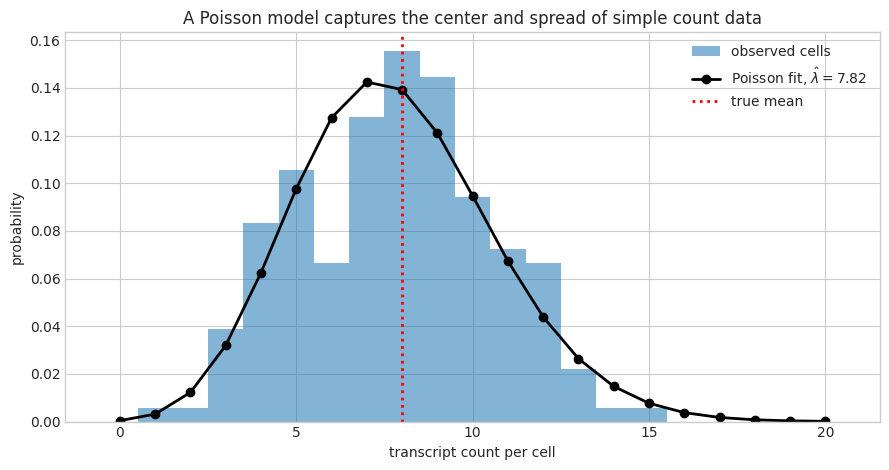

In [5]:
k_max = max(counts.max(), 20)
k_grid = np.arange(0, k_max + 1)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(counts, bins=np.arange(-0.5, k_max + 1.5, 1), density=True, alpha=0.55,
        color='tab:blue', label='observed cells')
ax.plot(k_grid, poisson_pmf(k_grid, sample_mean), color='black', marker='o', linewidth=2,
        label=fr'Poisson fit, $\hat\lambda = {sample_mean:.2f}$')
ax.axvline(lambda_true, color='red', linestyle=':', linewidth=2, label='true mean')

ax.set_xlabel('transcript count per cell')
ax.set_ylabel('probability')
ax.set_title('A Poisson model captures the center and spread of simple count data')
ax.legend()
plt.tight_layout()
plt.show()

## Step 3: Estimating the Rate Parameter

For independent observations $y_1, \dots, y_N$, the likelihood is

$$p(\mathbf{y} \mid \lambda) = \prod_{i=1}^N \frac{\lambda^{y_i} e^{-\lambda}}{y_i!}.$$

The log-likelihood is

$$\ell(\lambda) = \sum_i y_i \log\lambda - N\lambda - \sum_i \log(y_i!).$$

Differentiate with respect to $\lambda$ and set the derivative to zero:

$$\frac{d\ell}{d\lambda} = \frac{\sum_i y_i}{\lambda} - N = 0
\quad\Rightarrow\quad
\hat\lambda = \frac{1}{N}\sum_i y_i.$$

So the maximum-likelihood estimate is simply the sample mean.

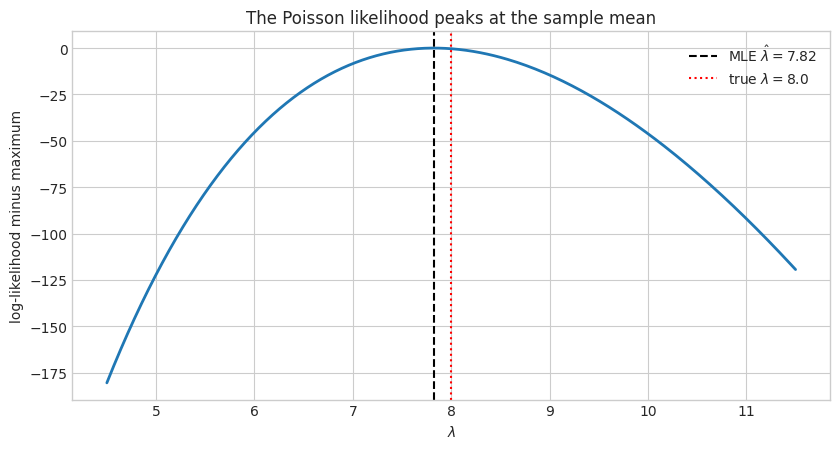

In [6]:
def poisson_loglikelihood(data, lam_values):
    data = np.asarray(data)
    lam_values = np.asarray(lam_values)
    constant = -sum(math.lgamma(int(y) + 1) for y in data)
    return data.sum() * np.log(lam_values) - len(data) * lam_values + constant

lam_values = np.linspace(4.5, 11.5, 300)
loglik = poisson_loglikelihood(counts, lam_values)
loglik_shifted = loglik - loglik.max()

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(lam_values, loglik_shifted, linewidth=2)
ax.axvline(sample_mean, color='black', linestyle='--', label=fr'MLE $\hat\lambda = {sample_mean:.2f}$')
ax.axvline(lambda_true, color='red', linestyle=':', label=fr'true $\lambda = {lambda_true:.1f}$')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('log-likelihood minus maximum')
ax.set_title('The Poisson likelihood peaks at the sample mean')
ax.legend()
plt.tight_layout()
plt.show()

## Step 4: Sampling Variability of the Estimate

Even when the model is exactly right, $\hat\lambda$ changes from experiment to experiment. Since a sum of independent Poisson variables is Poisson,

$$\sum_{i=1}^N Y_i \sim \mathrm{Poisson}(N\lambda).$$

Therefore,

$$\mathbb{E}[\hat\lambda] = \lambda, \qquad \mathrm{Var}(\hat\lambda) = \frac{\lambda}{N}.$$

A rough standard error is

$$\mathrm{SE}(\hat\lambda) \approx \sqrt{\frac{\hat\lambda}{N}}.$$

More cells make the estimate tighter at the familiar $1/\sqrt{N}$ rate.

MLE lambda:              7.822
approx standard error:   0.208
approx 95% interval:     [7.414, 8.231]


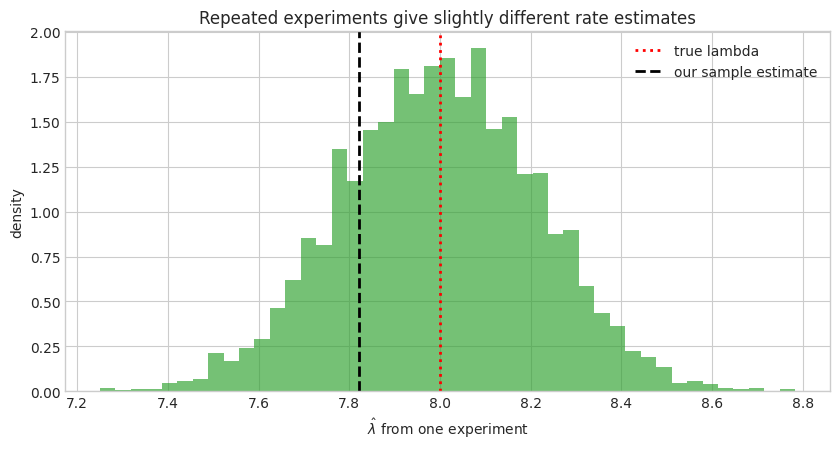

In [7]:
standard_error = np.sqrt(sample_mean / n_cells)
approx_interval = (sample_mean - 1.96 * standard_error, sample_mean + 1.96 * standard_error)

print(f'MLE lambda:              {sample_mean:.3f}')
print(f'approx standard error:   {standard_error:.3f}')
print(f'approx 95% interval:     [{approx_interval[0]:.3f}, {approx_interval[1]:.3f}]')

n_repeats = 5_000
means_from_repeated_experiments = np.random.poisson(lambda_true, size=(n_repeats, n_cells)).mean(axis=1)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.hist(means_from_repeated_experiments, bins=45, density=True, alpha=0.65, color='tab:green')
ax.axvline(lambda_true, color='red', linestyle=':', linewidth=2, label='true lambda')
ax.axvline(sample_mean, color='black', linestyle='--', linewidth=2, label='our sample estimate')
ax.set_xlabel(r'$\hat\lambda$ from one experiment')
ax.set_ylabel('density')
ax.set_title('Repeated experiments give slightly different rate estimates')
ax.legend()
plt.tight_layout()
plt.show()

## Step 5: Exposure and Cell-Size Factors

Poisson counts often depend on exposure. In sequencing, one cell may have more captured molecules than another because it has a larger library size or higher capture efficiency.

A simple exposure-adjusted model is

$$Y_i \sim \mathrm{Poisson}(s_i\lambda),$$

where $s_i$ is a known size factor. The expected count is no longer the same for every cell, but the normalized count $Y_i/s_i$ has expectation $\lambda$.

The maximum-likelihood estimate becomes

$$\hat\lambda = \frac{\sum_i y_i}{\sum_i s_i}.$$

naive mean count:        7.85
exposure-adjusted MLE:   7.85
true lambda:             8.00


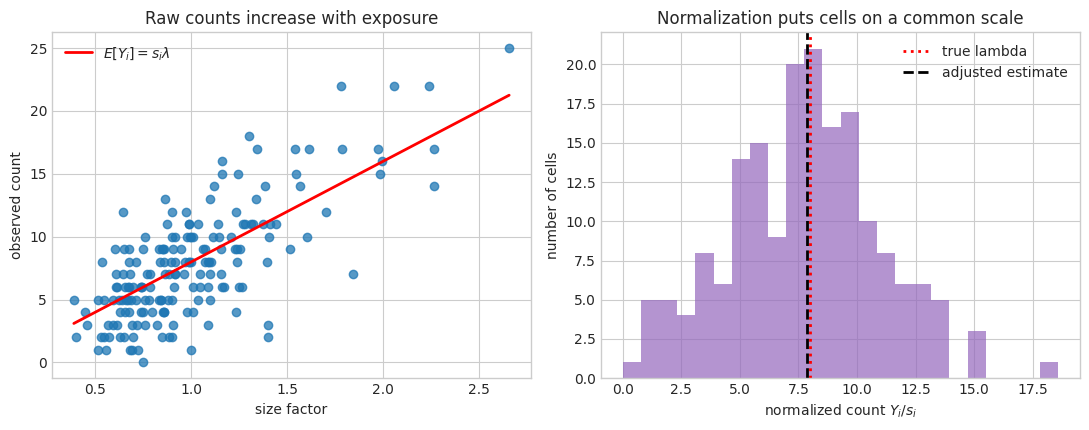

In [8]:
size_factors = np.random.lognormal(mean=0.0, sigma=0.35, size=n_cells)
size_factors = size_factors / size_factors.mean()
exposure_counts = np.random.poisson(size_factors * lambda_true)

naive_mean = exposure_counts.mean()
exposure_adjusted_mean = exposure_counts.sum() / size_factors.sum()
normalized_counts = exposure_counts / size_factors

print(f'naive mean count:        {naive_mean:.2f}')
print(f'exposure-adjusted MLE:   {exposure_adjusted_mean:.2f}')
print(f'true lambda:             {lambda_true:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

axes[0].scatter(size_factors, exposure_counts, alpha=0.75)
axes[0].plot(np.sort(size_factors), lambda_true * np.sort(size_factors), color='red', linewidth=2,
             label=fr'$E[Y_i] = s_i\lambda$')
axes[0].set_xlabel('size factor')
axes[0].set_ylabel('observed count')
axes[0].set_title('Raw counts increase with exposure')
axes[0].legend()

axes[1].hist(normalized_counts, bins=24, alpha=0.7, color='tab:purple')
axes[1].axvline(lambda_true, color='red', linestyle=':', linewidth=2, label='true lambda')
axes[1].axvline(exposure_adjusted_mean, color='black', linestyle='--', linewidth=2,
                label='adjusted estimate')
axes[1].set_xlabel(r'normalized count $Y_i / s_i$')
axes[1].set_ylabel('number of cells')
axes[1].set_title('Normalization puts cells on a common scale')
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 6: Additivity

If independent Poisson counts measure separate event streams, their sum is still Poisson. For example, if three independent transcript sources have rates $\lambda_1$, $\lambda_2$, and $\lambda_3$, then

$$Y_1 + Y_2 + Y_3 \sim \mathrm{Poisson}(\lambda_1 + \lambda_2 + \lambda_3).$$

This is one reason the Poisson distribution appears naturally in event-counting models: independent rates add.

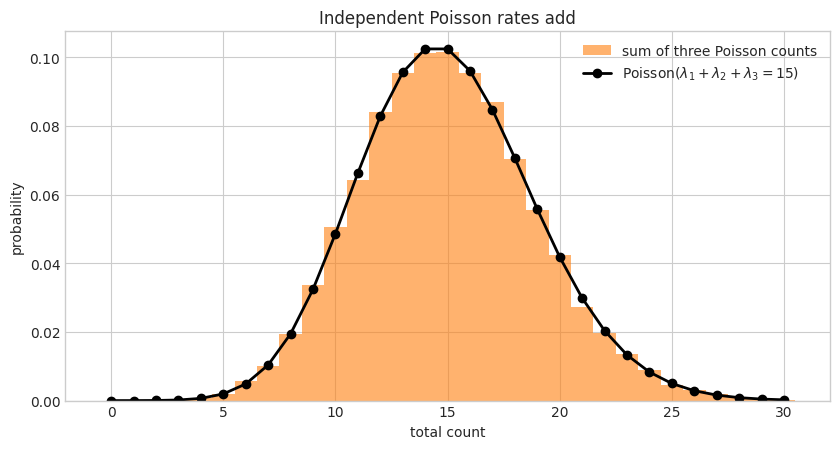

In [9]:
rates = np.array([2.0, 5.0, 8.0])
n_samples = 20_000
component_counts = np.random.poisson(rates, size=(n_samples, len(rates)))
total_counts = component_counts.sum(axis=1)

combined_rate = rates.sum()
k_grid = np.arange(0, total_counts.max() + 1)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.hist(total_counts, bins=np.arange(-0.5, total_counts.max() + 1.5, 1), density=True,
        alpha=0.6, color='tab:orange', label='sum of three Poisson counts')
ax.plot(k_grid, poisson_pmf(k_grid, combined_rate), color='black', marker='o', linewidth=2,
        label=fr'Poisson($\lambda_1 + \lambda_2 + \lambda_3 = {combined_rate:.0f}$)')
ax.set_xlabel('total count')
ax.set_ylabel('probability')
ax.set_title('Independent Poisson rates add')
ax.legend()
plt.tight_layout()
plt.show()

## Step 7: When Poisson is Too Simple

The Poisson distribution has a strong diagnostic property:

$$\frac{\mathrm{Var}(Y)}{\mathbb{E}[Y]} = 1.$$

This ratio is called the **Fano factor**. Real RNA-seq counts often have Fano factors larger than 1 because cells differ in hidden biological state, capture efficiency is imperfect, and transcription can occur in bursts.

One way overdispersion appears is through unobserved cell-to-cell variation in the rate:

$$Y_i \mid \lambda_i \sim \mathrm{Poisson}(\lambda_i), \qquad \lambda_i \text{ varies across cells}.$$

The marginal counts then have more variance than a single-rate Poisson model can explain.

Simple Poisson-like data
  mean=7.82, variance=7.40, Fano=0.95
Hidden-rate heterogeneous data
  mean=8.44, variance=45.86, Fano=5.43


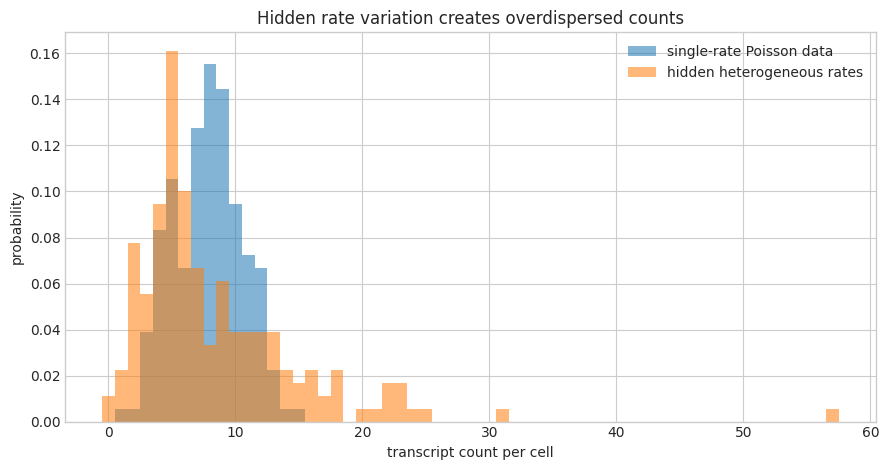

In [10]:
# Hidden heterogeneity: every cell has its own latent rate around the same average.
latent_rates = np.random.lognormal(mean=np.log(lambda_true) - 0.5 * 0.55**2, sigma=0.55, size=n_cells)
overdispersed_counts = np.random.poisson(latent_rates)

pois_mean = counts.mean()
pois_var = counts.var(ddof=1)
over_mean = overdispersed_counts.mean()
over_var = overdispersed_counts.var(ddof=1)

print('Simple Poisson-like data')
print(f'  mean={pois_mean:.2f}, variance={pois_var:.2f}, Fano={pois_var / pois_mean:.2f}')
print('Hidden-rate heterogeneous data')
print(f'  mean={over_mean:.2f}, variance={over_var:.2f}, Fano={over_var / over_mean:.2f}')

fig, ax = plt.subplots(figsize=(9, 4.8))
bins = np.arange(-0.5, max(counts.max(), overdispersed_counts.max()) + 1.5, 1)
ax.hist(counts, bins=bins, density=True, alpha=0.55, label='single-rate Poisson data')
ax.hist(overdispersed_counts, bins=bins, density=True, alpha=0.55, label='hidden heterogeneous rates')
ax.set_xlabel('transcript count per cell')
ax.set_ylabel('probability')
ax.set_title('Hidden rate variation creates overdispersed counts')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

The Poisson distribution is the basic model for nonnegative integer counts generated by independent events at a constant rate.

| Idea | Result |
|---|---|
| Probability mass | $p(k) = \frac{\lambda^k e^{-\lambda}}{k!}$ |
| Support | $k = 0, 1, 2, \dots$ |
| Mean | $\mathbb{E}[K] = \lambda$ |
| Variance | $\mathrm{Var}(K) = \lambda$ |
| MLE from iid counts | $\hat\lambda = \frac{1}{N}\sum_i y_i$ |
| Exposure-adjusted MLE | $\hat\lambda = \frac{\sum_i y_i}{\sum_i s_i}$ |
| Additivity | independent Poisson rates add |

Key takeaways:

1. Poisson is a natural first model for transcript counts, mutation counts, colony counts, or arrivals per unit time.
2. The single parameter $\lambda$ controls both the center and spread.
3. The sample mean estimates $\lambda$ because it maximizes the likelihood.
4. Exposure factors convert the model from $Y_i \sim \mathrm{Poisson}(\lambda)$ to $Y_i \sim \mathrm{Poisson}(s_i\lambda)$.
5. If the variance is much larger than the mean, the data are overdispersed and a negative binomial or hierarchical Poisson model is often more appropriate.